In [13]:
# Imports
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt



Define the Lorenz 63 Drift Function


In [14]:
true_sigma = 10.0
true_rho = 28.0
true_beta = 8.0 / 3.0
def drift_l63(x, sigma=true_sigma, rho=true_rho, beta=true_beta):
    """Lorenz '63 drift function."""
    x1, x2, x3 = x
    dx1 = sigma * (x2 - x1)
    dx2 = x1 * (rho - x3) - x2
    dx3 = x1 * x2 - beta * x3
    return jnp.array([dx1, dx2, dx3])

true_drift = lambda x: drift_l63(x) # Correctly-Specified model
slightly_bad_drift = lambda x: drift_l63(x, sigma=11.0) # Slightly Mis-Specified model
very_bad_drift = lambda x: drift_l63(x, sigma=25.0, rho=15.0, beta=10.0) # Highly Mis-Specified model

In [15]:
# System dimensions
state_dim = 3 # Lorenz '63 has 3 state dimensions
emission_dim = 1 # Here we choose to observe only the first dimension
H = jnp.eye(emission_dim, state_dim)

# Noise parameters
diffusion_coeff_true = 1.0
emission_sd_true = 5.0
initial_state_sd_true = 30.0

# Create the SSM
# Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
from cd_dynamax import ContDiscreteNonlinearGaussianSSM
cdnlgssm = ContDiscreteNonlinearGaussianSSM(state_dim=state_dim, emission_dim=emission_dim)

# Build the true parameters
true_params = cdnlgssm.build_params(
    drift=true_drift,
    initial_mean=jnp.zeros(state_dim),
    initial_cov=(initial_state_sd_true**2) * jnp.eye(state_dim),
    diffusion_coeff=diffusion_coeff_true * jnp.eye(state_dim),
    emission_function=lambda x: H @ x,
    emission_cov=(emission_sd_true**2) * jnp.eye(emission_dim),
)

# Build slightly bad parameters for comparison
slightly_bad_params = cdnlgssm.build_params(
    # Use mis-specified drift
    drift=slightly_bad_drift,
    # Keep other parameters the same
    initial_mean=jnp.zeros(state_dim),
    initial_cov=(initial_state_sd_true**2) * jnp.eye(state_dim),
    diffusion_coeff=diffusion_coeff_true * jnp.eye(state_dim),
    emission_function=lambda x: H @ x,
    emission_cov=(emission_sd_true**2) * jnp.eye(emission_dim),
)

# Build very bad parameters
very_bad_params = cdnlgssm.build_params(
    # Use mis-specified drift
    drift=very_bad_drift,
    # Keep other parameters the same
    initial_mean=jnp.zeros(state_dim),
    initial_cov=(initial_state_sd_true**2) * jnp.eye(state_dim),
    diffusion_coeff=diffusion_coeff_true * jnp.eye(state_dim),
    emission_function=lambda x: H @ x,
    emission_cov=(emission_sd_true**2) * jnp.eye(emission_dim),
)


Simulate data using true parameters

[make_t_emissions] Generated 1000 points from 0.0 to 100.0 with avg step ~0.1000
[make_t_emissions] Smallest time step = 0.000183
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


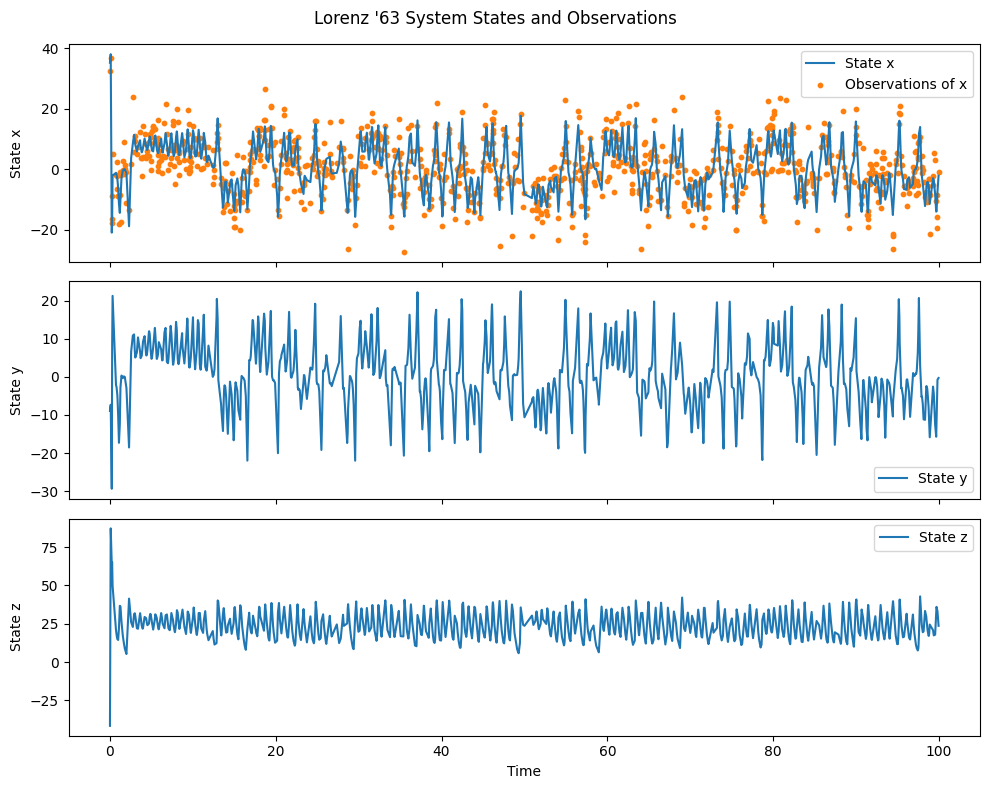

In [16]:
from cd_dynamax import make_key_sequence
from cd_dynamax.src.utils.demo_utils import sample_t_emissions

keys = make_key_sequence(0)
t_emissions = sample_t_emissions(start=0.0, stop=100.0, dt=0.1, regular=False, key=next(keys))

# Simulate data using true parameters (observed at times t_emissions)
# Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
states, emissions = cdnlgssm.sample(
    params=true_params,
    key=next(keys),
    num_timesteps=len(t_emissions),
    t_emissions=t_emissions,
    transition_type="path",
)

# Plot the results in a subplot with 3 rows, with observations overlaid in first emission_dims rows
fig, axs = plt.subplots(state_dim, 1, figsize=(10, 8), sharex=True)
state_labels = ['x', 'y', 'z']
for i in range(state_dim):
    axs[i].plot(t_emissions, states[:, i], label=f'State {state_labels[i]}', color='C0')
    if i < emission_dim:
        axs[i].scatter(t_emissions, emissions[:, i], label=f'Observations of {state_labels[i]}', color='C1', s=10)
    axs[i].legend()
    axs[i].set_ylabel(f'State {state_labels[i]}')
axs[-1].set_xlabel('Time')
plt.suptitle('Lorenz \'63 System States and Observations')
plt.tight_layout()
plt.show()

Now perform filtering over the observed emissions using EnKF. This produces filtered state estimates at the observation times, but also, crucially, computes an estimate of the log likelihood of the observed data under the model.

In [17]:
def filter_and_compute_loglik(params, title="True parameters", T=None):
    
    if T is None:
        T = len(emissions)

    emissions_to_use = emissions[:T]
    t_emissions_to_use = t_emissions[:T]
    states_to_use = states[:T]
    

    # Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
    filtered = cdnlgssm.filter(
        params=params,
        emissions=emissions_to_use,
        t_emissions=t_emissions_to_use,
        key=next(keys),
        N_particles=100,
    )

    print(f"Log likelihood {title}:", float(filtered.marginal_loglik))

    # Plot a subfigure with state_dim rows showing true state, filtered mean and (optionally via shaded region) filtered stddev.
    # Also plot the observations in the first emission_dim rows.
    fig, axs = plt.subplots(state_dim, 1, figsize=(10, 8), sharex=True)
    for i in range(state_dim):
        axs[i].plot(t_emissions_to_use, states_to_use[:, i], label=f'True State {state_labels[i]}', color='C0')
        axs[i].plot(t_emissions_to_use, filtered.filtered_means[:, i], label=f'Filtered Mean {state_labels[i]}', color='C1')
        axs[i].fill_between(
            t_emissions_to_use.squeeze(),
            filtered.filtered_means[:, i] - 2 * jnp.sqrt(filtered.filtered_covariances[:, i, i]),
            filtered.filtered_means[:, i] + 2 * jnp.sqrt(filtered.filtered_covariances[:, i, i]),
            color='C1',
            alpha=0.3,
            label=f'Filtered ±2 Stddev {state_labels[i]}'
        )
        if i < emission_dim:
            axs[i].scatter(t_emissions_to_use, emissions_to_use[:, i], label=f'Observations of {state_labels[i]}', color='C2', s=10)
        axs[i].legend(loc='upper right')
        axs[i].set_ylabel(f'State {state_labels[i]}')
    axs[-1].set_xlabel('Time')
    plt.suptitle(title)
    plt.tight_layout()

    return filtered.marginal_loglik
        

Now we can compute the log likelihood at the true parameters, then at the mis-specified parameters. We will visualize the resulting filtering distributions as well to give intuitition for why the log likelihoods differ. 

The likelihood should decrease when the parameters get further from the truth---the true parameters should yield the highest log-likelihood. If they don't, then the finite-amount of noisy data is at likely play---those two models are not distinguishable given the data. This is typically why we use Bayesian methods to quantify uncertainty in parameter estimates.

CAVEAT: the likelihood approximation is stochastic and approximate.

Log likelihood Filtering Results at True Parameters: -326.16028554799766
Log likelihood Filtering Results at Slightly Bad Parameters: -326.8370719280746
Log likelihood Filtering Results at Very Bad Parameters: -895.7091001300375


Array(-895.70910013, dtype=float64)

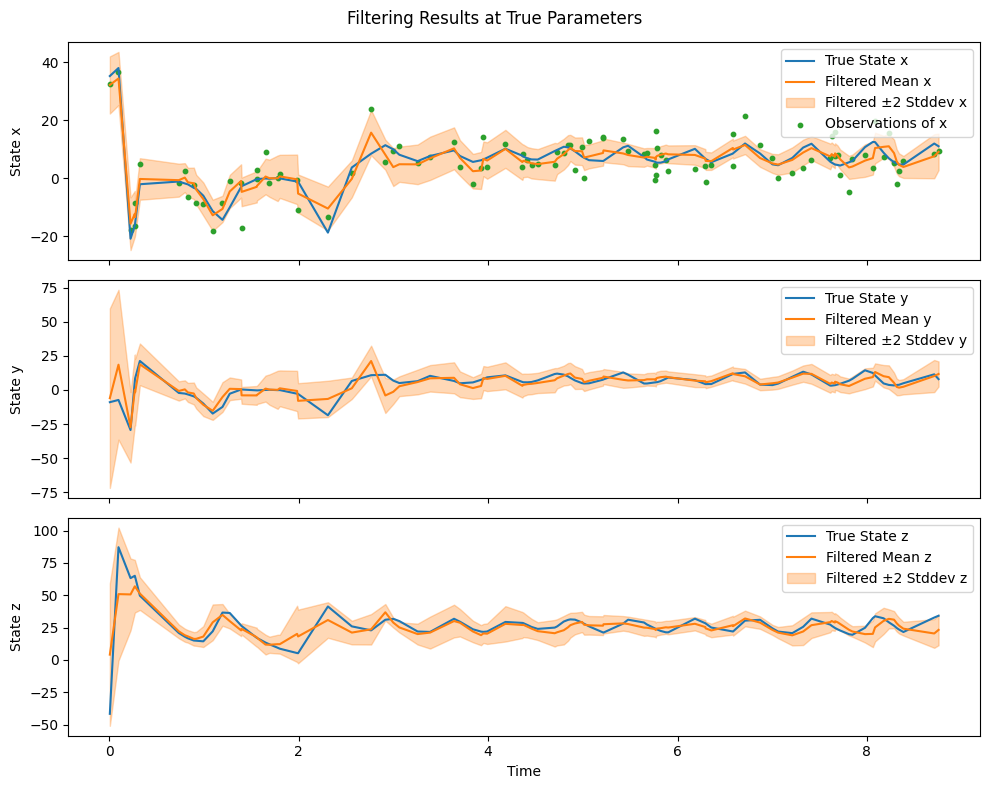

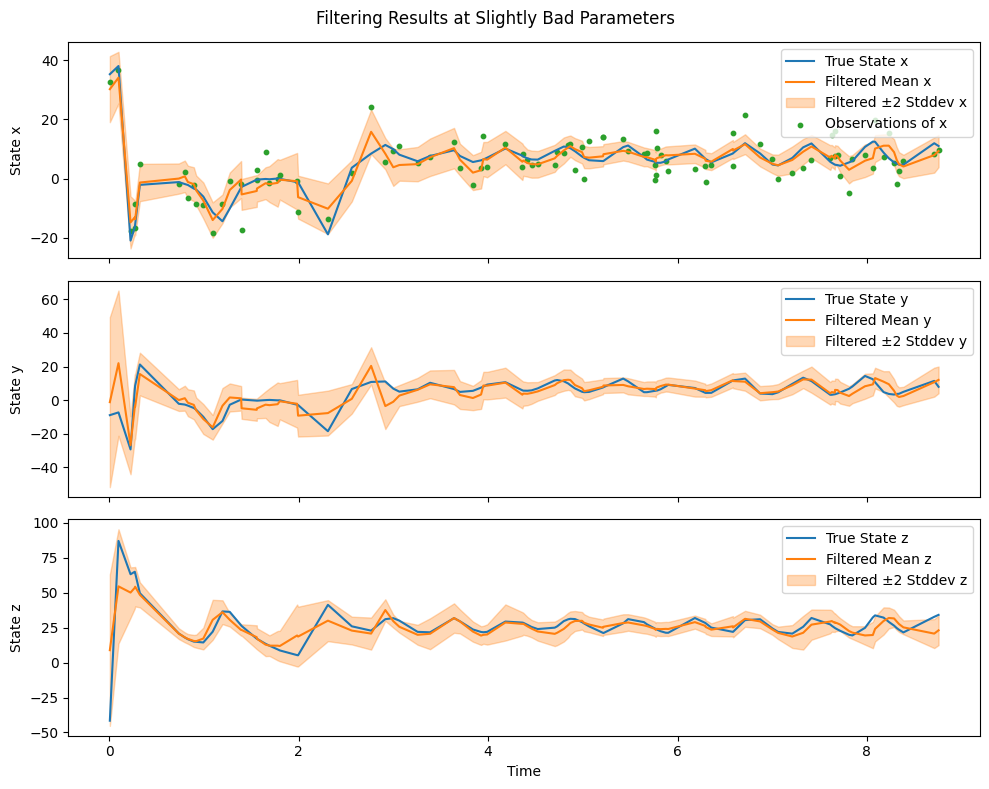

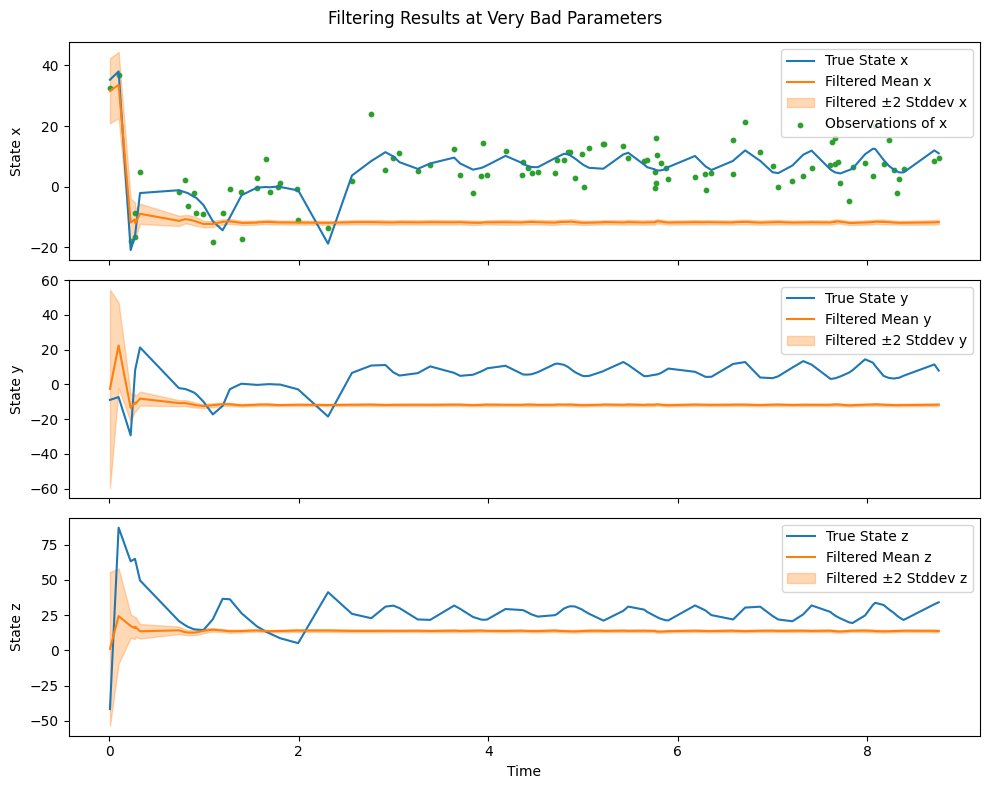

In [18]:
# Run for 10% of data for easy visualization and fast computation.
filter_and_compute_loglik(true_params, title="Filtering Results at True Parameters", T=len(emissions)//10)
filter_and_compute_loglik(slightly_bad_params, title="Filtering Results at Slightly Bad Parameters", T=len(emissions)//10)
filter_and_compute_loglik(very_bad_params, title="Filtering Results at Very Bad Parameters", T=len(emissions)//10)

Now, let's sweep over Rho (holding sigma and beta fixed at true values) to see how the log likelihood varies with this parameter. We should see a peak around the true value of Rho=28.0, but we know that the amount of data is limited and the likelihood is approximate, so we may not see this exactly. If you want to see an unbiased peak, try increasing the amount of data (T) and number of particles.


In [19]:
def compute_likelihood_at_rho(rho_value, T=None, N_particles=100):
    
    if T is None:
        T = len(emissions)
    
    emissions_to_use = emissions[:T]
    t_emissions_to_use = t_emissions[:T]
    
    # Build parameters with given sigma value
    params = cdnlgssm.build_params(
        # Use drift with specified sigma
        drift=lambda x: drift_l63(x, rho=rho_value),
        # all other parameters same as true
        initial_mean=jnp.zeros(state_dim),
        initial_cov=(initial_state_sd_true**2) * jnp.eye(state_dim),
        diffusion_coeff=diffusion_coeff_true * jnp.eye(state_dim),
        emission_function=lambda x: H @ x,
        emission_cov=(emission_sd_true**2) * jnp.eye(emission_dim),
    )

    # Run filtering to compute log likelihood
    filtered = cdnlgssm.filter(
        params=params,
        emissions=emissions_to_use,
        t_emissions=t_emissions_to_use,
        key=next(keys), # if you comment this out, you'll get deterministic results (the EnKF will always be seeded with jr.PRNGKey(0))
        N_particles=N_particles,
    )
    
    return filtered.marginal_loglik

In [20]:
def rho_sweep_experiment(T=None, N_particles=100, do_slow_loops=False):
    if T is None:
        T = len(emissions)

    def _compute_likelihood_at_rho(rho):
        return compute_likelihood_at_rho(rho, T=T, N_particles=N_particles)
    
    rho_values = jnp.linspace(10.0, 50.0, 20)
    # In JAX, we can use vmap to compute log likelihoods in parallel (via vectorization). Let's time it, and compare to a for-loop and a lax.scan (a JAX sped-up version of a for-loop).
    from time import time
    # Using vmap
    from jax import vmap
    start_time = time()
    print("Note that vmap can trigger un-hit warnings, so don't be alarmed if you see them here.")
    loglik_values_vmap = vmap(_compute_likelihood_at_rho)(rho_values)
    vmap_time = time() - start_time
    print(f"vmap time: {vmap_time:.2f} seconds")

    if do_slow_loops:
        # Using for-loop
        start_time = time()
        loglik_values_loop = []
        for rho in rho_values:
            loglik = _compute_likelihood_at_rho(rho)
            loglik_values_loop.append(loglik)
        loglik_values_loop = jnp.array(loglik_values_loop)
        loop_time = time() - start_time
        print(f"For-loop time: {loop_time:.2f} seconds")

        # Using lax.scan
        from jax import lax
        def scan_step(carry, rho):
            loglik = _compute_likelihood_at_rho(rho)
            return carry, loglik
        start_time = time()
        _, loglik_values_scan = lax.scan(scan_step, None, rho_values)
        scan_time = time() - start_time
        print(f"lax.scan time: {scan_time:.2f} seconds")

        # Using pmap if you have access to multiple devices (this is parallelization across devices, not vectorization)
        try:
            from jax import pmap
            start_time = time()
            loglik_values_pmap = pmap(_compute_likelihood_at_rho)(rho_values)
            pmap_time = time() - start_time
            print(f"pmap time: {pmap_time:.2f} seconds")
        except Exception as e:
            print("pmap not available or failed to run:", e)
    
    # Plot the log likelihood vs Rho
    # Note that because the likelihood is stochastic and approximate, the curves may not be perfectly smooth or peak exactly at the true parameter value.
    # These curves should be similar, but may have slight differences due to the stochastic nature of the EnKF at each call.
    # That is, there is no difference between vmap, for-loop, and lax.scan in terms of the results other than the order of random numbers used (and POSSIBLY some small hardware-dependent numerical differences).
    # To get perfectly identical results, you would need to fix the random seed inside compute_likelihood_at_sigma, which is shown above in the comments.
    plt.figure(figsize=(10, 6))
    plt.plot(rho_values, loglik_values_vmap, label='vmap', marker='o')
    if do_slow_loops:
        plt.plot(rho_values, loglik_values_loop, label='for-loop', marker='x')
        plt.plot(rho_values, loglik_values_scan, label='lax.scan', marker='s')
    plt.axvline(x=true_rho, color='k', linestyle=':', label='True Rho')
    plt.xlabel('Rho Value')
    plt.ylabel('Log Likelihood')
    plt.title(f'Log Likelihood vs Rho Value for data up to T={T} with N_particles={N_particles}')
    plt.legend()
    plt.show()

Note that vmap can trigger un-hit warnings, so don't be alarmed if you see them here.
vmap time: 1.69 seconds


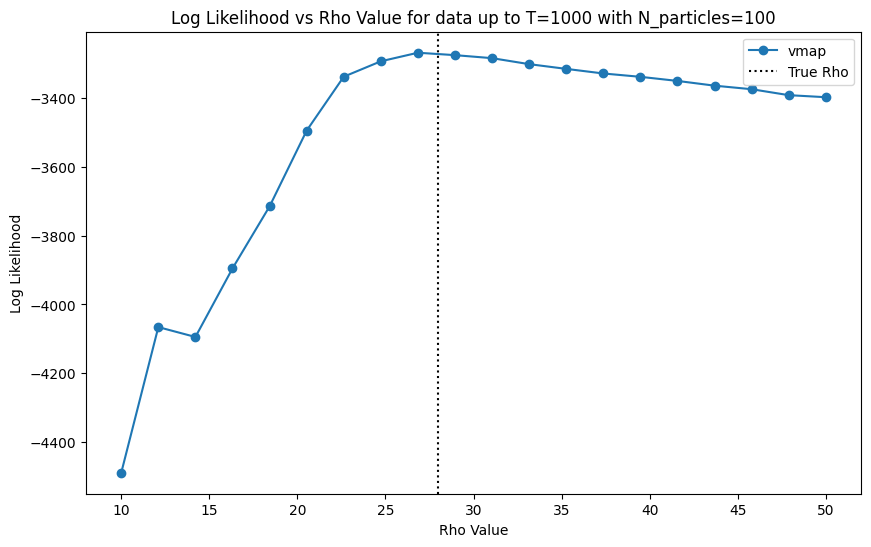

In [21]:
# Run sweep experiment with all data
rho_sweep_experiment(T=len(emissions), N_particles=100)

Note that vmap can trigger un-hit warnings, so don't be alarmed if you see them here.
vmap time: 1.07 seconds


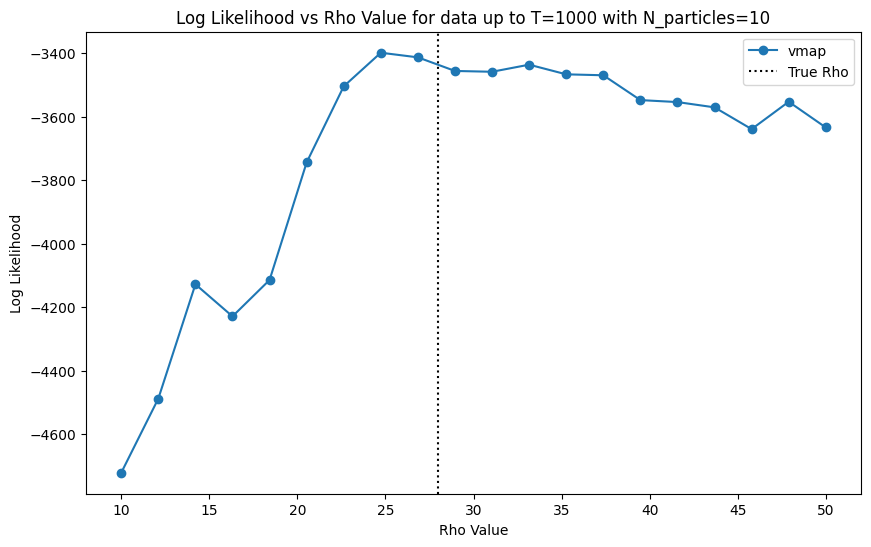

In [22]:
# Run sweep experiment with all data but few particles (bad approximation). Notice that it is jagged, and does not peak at the true value. This is due to high variance in the likelihood estimate with few particles.
rho_sweep_experiment(T=len(emissions), N_particles=10)

Note that vmap can trigger un-hit warnings, so don't be alarmed if you see them here.
vmap time: 0.80 seconds
For-loop time: 13.48 seconds
lax.scan time: 1.87 seconds
pmap not available or failed to run: compiling computation that requires 20 logical devices, but only 1 XLA devices are available (num_replicas=20)


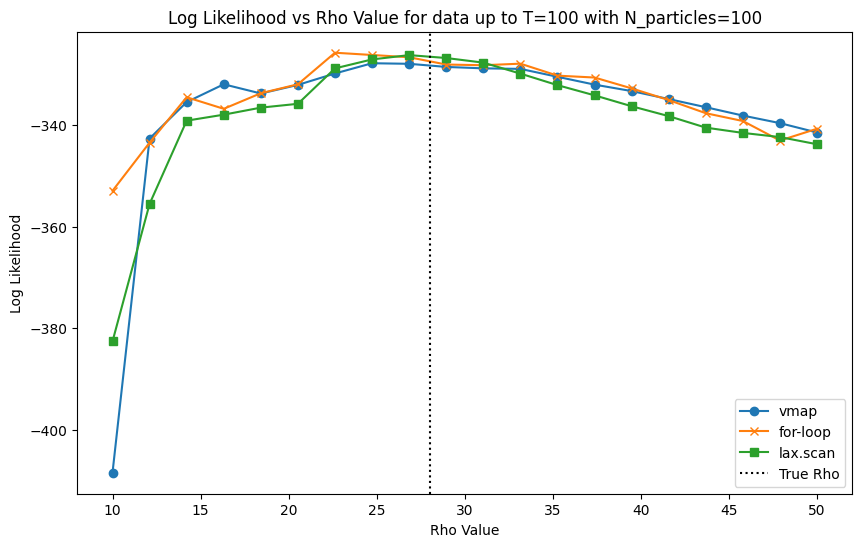

In [23]:
# Run sweep experiment with 10% of data. "Do slow loops" to see timing comparison between vmap, for-loop, and lax.scan.
# Here, we see that the likelihood peaks near the true value, but it is very flat in that region---that is due to limited data. 100 particles is likely sufficient to get a good approximation here.
rho_sweep_experiment(T=len(emissions)//10, N_particles=100, do_slow_loops=True)

Note that vmap can trigger un-hit warnings, so don't be alarmed if you see them here.
vmap time: 0.72 seconds


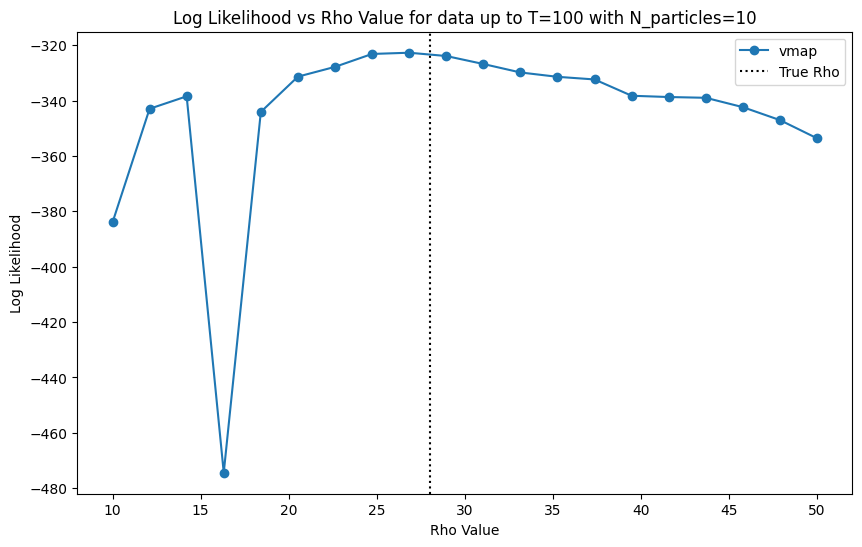

In [24]:
# Run sweep experiment with 10% of data and few particles.
# Now with small data and few particles, the likelihood is very noisy and also does not peak exactly at the true value (due to both limited data and high variance in the likelihood estimate).
# This is the noisiest of the experiments, and you can imagine that using such a likelihood could make parameter estimation / uncertainty quantification quite difficult! e.g., it introduces a spurious multimodality.
rho_sweep_experiment(T=len(emissions)//10, N_particles=10)